<a href="https://colab.research.google.com/github/antas06/DL_Scratch/blob/Root_functions/MAE_and__MSE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MSE Model
Slope     : 2.589951536362622
Intercept : 10.806510914609202
Test MSE  : 10.992927723325225
Test MAE  : 2.349013004694266

MAE Model
Slope     : 2.869730901045582
Intercept : 6.620419437048619
Test MSE  : 4.508230909756271
Test MAE  : 1.9964883634049702


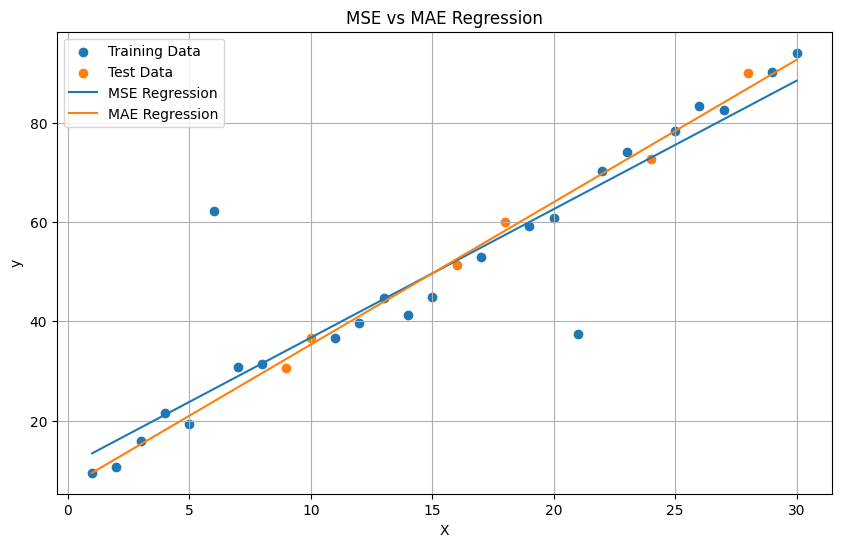

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.optimize import minimize

np.random.seed(42)

X = np.arange(1, 31, dtype=float)
y = 3 * X + 5 + np.random.normal(0, 3, len(X))

# Add outliers
y[5] += 40
y[20] -= 35

X = X.reshape(-1, 1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


def mse_loss(params, X, y):
    slope, intercept = params

    predictions = slope * X.ravel() + intercept

    return np.mean((y - predictions) ** 2)



def mae_loss(params, X, y):
    slope, intercept = params

    predictions = slope * X.ravel() + intercept

    return np.mean(np.abs(y - predictions))


mse_result = minimize(
    mse_loss,
    x0=[1, 0],
    args=(X_train, y_train)
)

mse_slope, mse_intercept = mse_result.x


mae_result = minimize(
    mae_loss,
    x0=[1, 0],
    args=(X_train, y_train),
    method="Powell"
)

mae_slope, mae_intercept = mae_result.x


mse_predictions = (
    mse_slope * X_test.ravel() + mse_intercept
)

mae_predictions = (
    mae_slope * X_test.ravel() + mae_intercept
)


mse_model_mse = mean_squared_error(
    y_test,
    mse_predictions
)

mse_model_mae = mean_absolute_error(
    y_test,
    mse_predictions
)

mae_model_mse = mean_squared_error(
    y_test,
    mae_predictions
)

mae_model_mae = mean_absolute_error(
    y_test,
    mae_predictions
)


print("MSE Model")
print("Slope     :", mse_slope)
print("Intercept :", mse_intercept)
print("Test MSE  :", mse_model_mse)
print("Test MAE  :", mse_model_mae)


print("\nMAE Model")
print("Slope     :", mae_slope)
print("Intercept :", mae_intercept)
print("Test MSE  :", mae_model_mse)
print("Test MAE  :", mae_model_mae)



x_line = np.linspace(
    X.min(),
    X.max(),
    200
)

mse_line = mse_slope * x_line + mse_intercept
mae_line = mae_slope * x_line + mae_intercept

plt.figure(figsize=(10, 6))

plt.scatter(
    X_train,
    y_train,
    label="Training Data"
)

plt.scatter(
    X_test,
    y_test,
    label="Test Data"
)

plt.plot(
    x_line,
    mse_line,
    label="MSE Regression"
)

plt.plot(
    x_line,
    mae_line,
    label="MAE Regression"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("MSE vs MAE Regression")
plt.legend()
plt.grid(True)

plt.show()